# 05 — Circadian clock disruption across disease trajectory

Investigates the anti-correlation between circadian clock output genes
(`Dbp`, `Nr1d1`/Rev-Erb-alpha, `Hlf`) and inflammatory markers across
the PLP relapsing-remitting EAE trajectory.

**Key questions**:
1. Is the circadian suppression at disease peaks a real within-cell-type
   phenomenon, or just a cell type composition effect?
2. Which cell types carry the circadian signal?
3. Does the core clock oscillator (`Arntl`, `Clock`) remain stable
   while the output arm is selectively disrupted?

**Background**: `Nr1d1` (Rev-Erb-alpha) is both a clock component and
a direct repressor of NF-kB-driven inflammatory genes. Rev-Erb-alpha
agonists reduce EAE severity in mice. If the circadian suppression at
peaks is cell-intrinsic (not just composition), it strengthens the case
for circadian-immune crosstalk as a mechanism in relapsing-remitting disease.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../src")

import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse

from temporal_foundation.config import (
    STAGE_KEY, MODEL_KEY, get_all_stages, model_short_name,
)
from temporal_foundation.data import load_adata


In [2]:
adata = load_adata()
adata.obs["model_short"] = adata.obs[MODEL_KEY].map(model_short_name)

# PLP subset, normalized
plp = adata[adata.obs["model_short"] == "PLP"].copy()
sc.pp.normalize_total(plp, target_sum=1e4)
sc.pp.log1p(plp)

plp_stages = get_all_stages()["PLP"]
plp.obs[STAGE_KEY] = pd.Categorical(plp.obs[STAGE_KEY], categories=plp_stages, ordered=True)

CELL_TYPE_KEY = "anno_L2"
print(f"PLP cells: {plp.n_obs:,}")
print(f"Stages: {plp_stages}")
print(f"Cell types: {plp.obs[CELL_TYPE_KEY].nunique()}")


Loading /Volumes/processing2/RRmap/data/rrmap.companion.ready.h5ad...

Loaded 877,141 cells, 5101 genes, 107 samples

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


PLP cells: 608,429
Stages: ['PLP CFA', 'ONSET1', 'ONSET2', 'MONOPHASIC', 'PEAK1', 'REMISSION1', 'PEAK2', 'REMISSION2', 'PEAK3']
Cell types: 21


## 1. Circadian vs inflammatory programs across the trajectory

Compare clock output genes (`Dbp`, `Nr1d1`, `Hlf`), core oscillator genes
(`Arntl`, `Clock`, `Per2`, `Cry1`), and inflammatory markers (`Stat1`, `Irf1`,
`Psmb8`, `Gbp2`, `Trem2`, `Gpnmb`) across all PLP stages.


Clock genes in panel: ['Dbp', 'Nr1d1', 'Hlf', 'Arntl', 'Clock', 'Per2', 'Cry1']


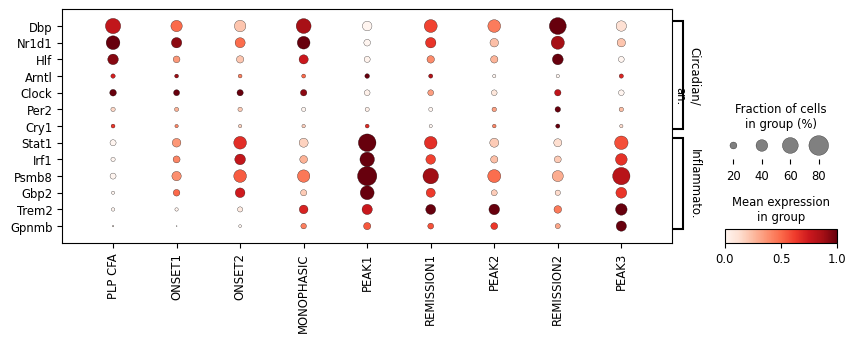

In [5]:
# Circadian / anti-inflammatory gene trajectory
clock_genes = ['Dbp', 'Nr1d1', 'Hlf', 'Arntl', 'Clock', 'Per2', 'Cry1']
# Filter to genes present in the dataset
clock_present = [g for g in clock_genes if g in plp.var_names]
print(f'Clock genes in panel: {clock_present}')

# Also add the inflammatory markers for contrast
inflam_genes = ['Stat1', 'Irf1', 'Psmb8', 'Gbp2', 'Trem2', 'Gpnmb']
inflam_present = [g for g in inflam_genes if g in plp.var_names]

contrast_groups = {}
if clock_present:
    contrast_groups['Circadian/\nanti-inflammatory'] = clock_present
if inflam_present:
    contrast_groups['Inflammatory'] = inflam_present

if contrast_groups:
    sc.pl.dotplot(plp, var_names=contrast_groups, groupby=STAGE_KEY,
                  standard_scale='var', swap_axes=True,
                  figsize=(10, (len(clock_present) + len(inflam_present)) * 0.2))
    plt.show()




### Circadian vs inflammatory programs: interpretation

The circadian output genes (`Dbp`, `Nr1d1`, `Hlf`) and the inflammatory genes
(`Stat1`, `Irf1`, `Psmb8`, `Gbp2`) show a clear **anti-correlated pattern**
across the PLP trajectory:

- **PEAK1** is the sharpest circadian disruption — `Dbp`/`Nr1d1`/`Hlf` essentially
  disappear. This is the IFN-gamma storm stage (`Stat1`, `Irf1` at maximum).
- **REMISSION1** is intermediate — circadian genes partially recover but inflammatory
  genes (`Psmb8`, `Stat1`) are still visible. Molecular armed truce, not true recovery.
- **REMISSION2** shows the strongest circadian recovery — `Dbp` and `Nr1d1` return
  to near-baseline levels. This is the deepest molecular remission.
- **PEAK3** suppresses circadian genes again, but less completely than PEAK1,
  consistent with a shift from acute IFN-gamma immunity to chronic foam cell
  pathology (`Trem2`, `Gpnmb` — a separate program that builds progressively).

**Why this is likely biological, not a sacrifice-time artifact**: the core clock
genes `Arntl` (BMAL1), `Clock`, `Per2`, and `Cry1` do not fluctuate as
dramatically. A time-of-day effect would suppress the entire clock uniformly.
The selective loss of the output/anti-inflammatory arm (`Dbp`, `Nr1d1`, `Hlf`)
while the core oscillator persists is the expected signature of **NF-kB-mediated
clock disruption** — inflammatory signaling suppresses clock output without
destroying the oscillator itself.

`Nr1d1` (Rev-Erb-alpha) is particularly relevant: it is both a clock component
and a direct repressor of inflammatory gene expression in macrophages.
Rev-Erb-alpha agonists have been shown to reduce EAE severity in mice.
Its restoration at remission may reflect active re-engagement of
anti-inflammatory circadian programs, not just passive resolution of
inflammation.


### Is the circadian signal cell-type dependent?

If `Dbp`/`Nr1d1`/`Hlf` are only expressed in one cell type (e.g. astrocytes),
the circadian pattern could be a proxy for composition changes — fewer astrocytes
at peaks, more at remissions. To rule this out, check:

1. Which cell types express the circadian genes?
2. Within each cell type, does the peak-suppression pattern still hold?


In [6]:
# Which cell types express circadian genes?
CELL_TYPE_KEY = "anno_L2"
clock_genes = ['Dbp', 'Nr1d1', 'Hlf']
clock_present = [g for g in clock_genes if g in plp.var_names]

# Mean expression per cell type (using the already-normalized plp object)
ct_expr = {}
for ct in sorted(plp.obs[CELL_TYPE_KEY].dropna().unique()):
    mask = plp.obs[CELL_TYPE_KEY] == ct
    n_cells = mask.sum()
    if n_cells < 50:
        continue
    sub = plp[mask]
    means = {}
    frac_expressing = {}
    for gene in clock_present:
        gi = list(plp.var_names).index(gene)
        vals = sub.X[:, gi]
        if sparse.issparse(vals):
            vals = np.asarray(vals.todense()).flatten()
        means[gene] = vals.mean()
        frac_expressing[gene] = (vals > 0).mean()
    ct_expr[ct] = {'n_cells': n_cells, 'means': means, 'frac': frac_expressing}

# Print sorted by Dbp expression
print(f"Circadian gene expression by cell type (PLP cells):\n")
print(f"{'Cell type':30s}  {'n_cells':>8s}  ", end='')
for g in clock_present:
    print(f"  {g:>6s} (mean)  {g:>6s} (%+)", end='')
print()
print('-' * 120)

sorted_cts = sorted(ct_expr.keys(),
                    key=lambda ct: ct_expr[ct]['means'].get('Dbp', 0), reverse=True)
for ct in sorted_cts:
    info = ct_expr[ct]
    print(f"{ct:30s}  {info['n_cells']:>8,}  ", end='')
    for g in clock_present:
        print(f"  {info['means'][g]:>10.3f}  {info['frac'][g]:>10.1%}", end='')
    print()


Circadian gene expression by cell type (PLP cells):

Cell type                        n_cells       Dbp (mean)     Dbp (%+)   Nr1d1 (mean)   Nr1d1 (%+)     Hlf (mean)     Hlf (%+)
------------------------------------------------------------------------------------------------------------------------
Pericyte                           6,064         2.025       74.0%       1.614       61.6%       1.178       48.1%
Astrocyte                         69,327         1.943       73.0%       1.567       62.1%       0.643       29.1%
Other                              3,803         1.832       66.5%       1.135       44.5%       0.549       22.7%
VSMC                               5,074         1.733       61.1%       1.475       53.6%       0.857       33.9%
Arachnoid barrier                 10,772         1.645       57.5%       1.125       41.2%       1.759       61.9%
Endothelial                       40,018         1.519       56.9%       1.192       46.8%       0.768       32.0%
Interneur

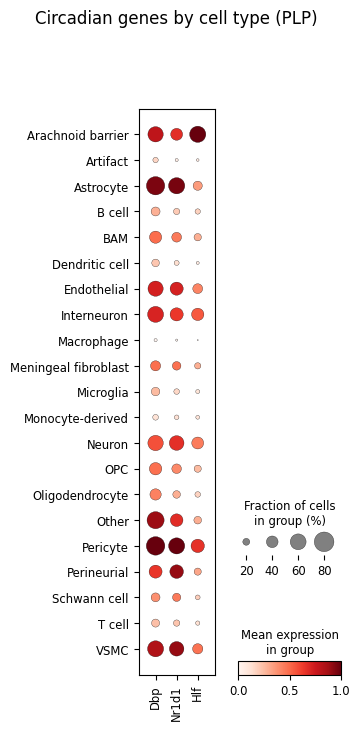

In [7]:
# Dotplot: circadian genes by cell type
sc.pl.dotplot(plp, var_names=clock_present, groupby=CELL_TYPE_KEY,
              standard_scale='var',
              title='Circadian genes by cell type (PLP)')
plt.show()


In [8]:
# Within each major cell type: circadian expression across stages
# Does the peak-suppression pattern hold WITHIN a cell type?

# Pick cell types that express Dbp (mean > 0.1)
expressing_cts = [ct for ct in sorted_cts
                  if ct_expr[ct]['means'].get('Dbp', 0) > 0.1
                  and ct_expr[ct]['n_cells'] > 500]

print(f"Cell types with Dbp mean > 0.1 and n > 500: {len(expressing_cts)}")
for ct in expressing_cts:
    print(f"  {ct} (n={ct_expr[ct]['n_cells']:,}, Dbp mean={ct_expr[ct]['means']['Dbp']:.3f})")


Cell types with Dbp mean > 0.1 and n > 500: 21
  Pericyte (n=6,064, Dbp mean=2.025)
  Astrocyte (n=69,327, Dbp mean=1.943)
  Other (n=3,803, Dbp mean=1.832)
  VSMC (n=5,074, Dbp mean=1.733)
  Arachnoid barrier (n=10,772, Dbp mean=1.645)
  Endothelial (n=40,018, Dbp mean=1.519)
  Interneuron (n=83,708, Dbp mean=1.495)
  Perineurial (n=4,587, Dbp mean=1.379)
  Neuron (n=29,210, Dbp mean=1.240)
  BAM (n=10,427, Dbp mean=1.100)
  Meningeal fibroblast (n=30,748, Dbp mean=1.084)
  OPC (n=15,916, Dbp mean=1.083)
  Oligodendrocyte (n=119,979, Dbp mean=0.982)
  Schwann cell (n=13,915, Dbp mean=0.896)
  B cell (n=9,286, Dbp mean=0.721)
  Microglia (n=78,534, Dbp mean=0.663)
  T cell (n=23,937, Dbp mean=0.637)
  Dendritic cell (n=11,257, Dbp mean=0.591)
  Artifact (n=6,733, Dbp mean=0.500)
  Monocyte-derived (n=4,335, Dbp mean=0.410)
  Macrophage (n=30,799, Dbp mean=0.205)


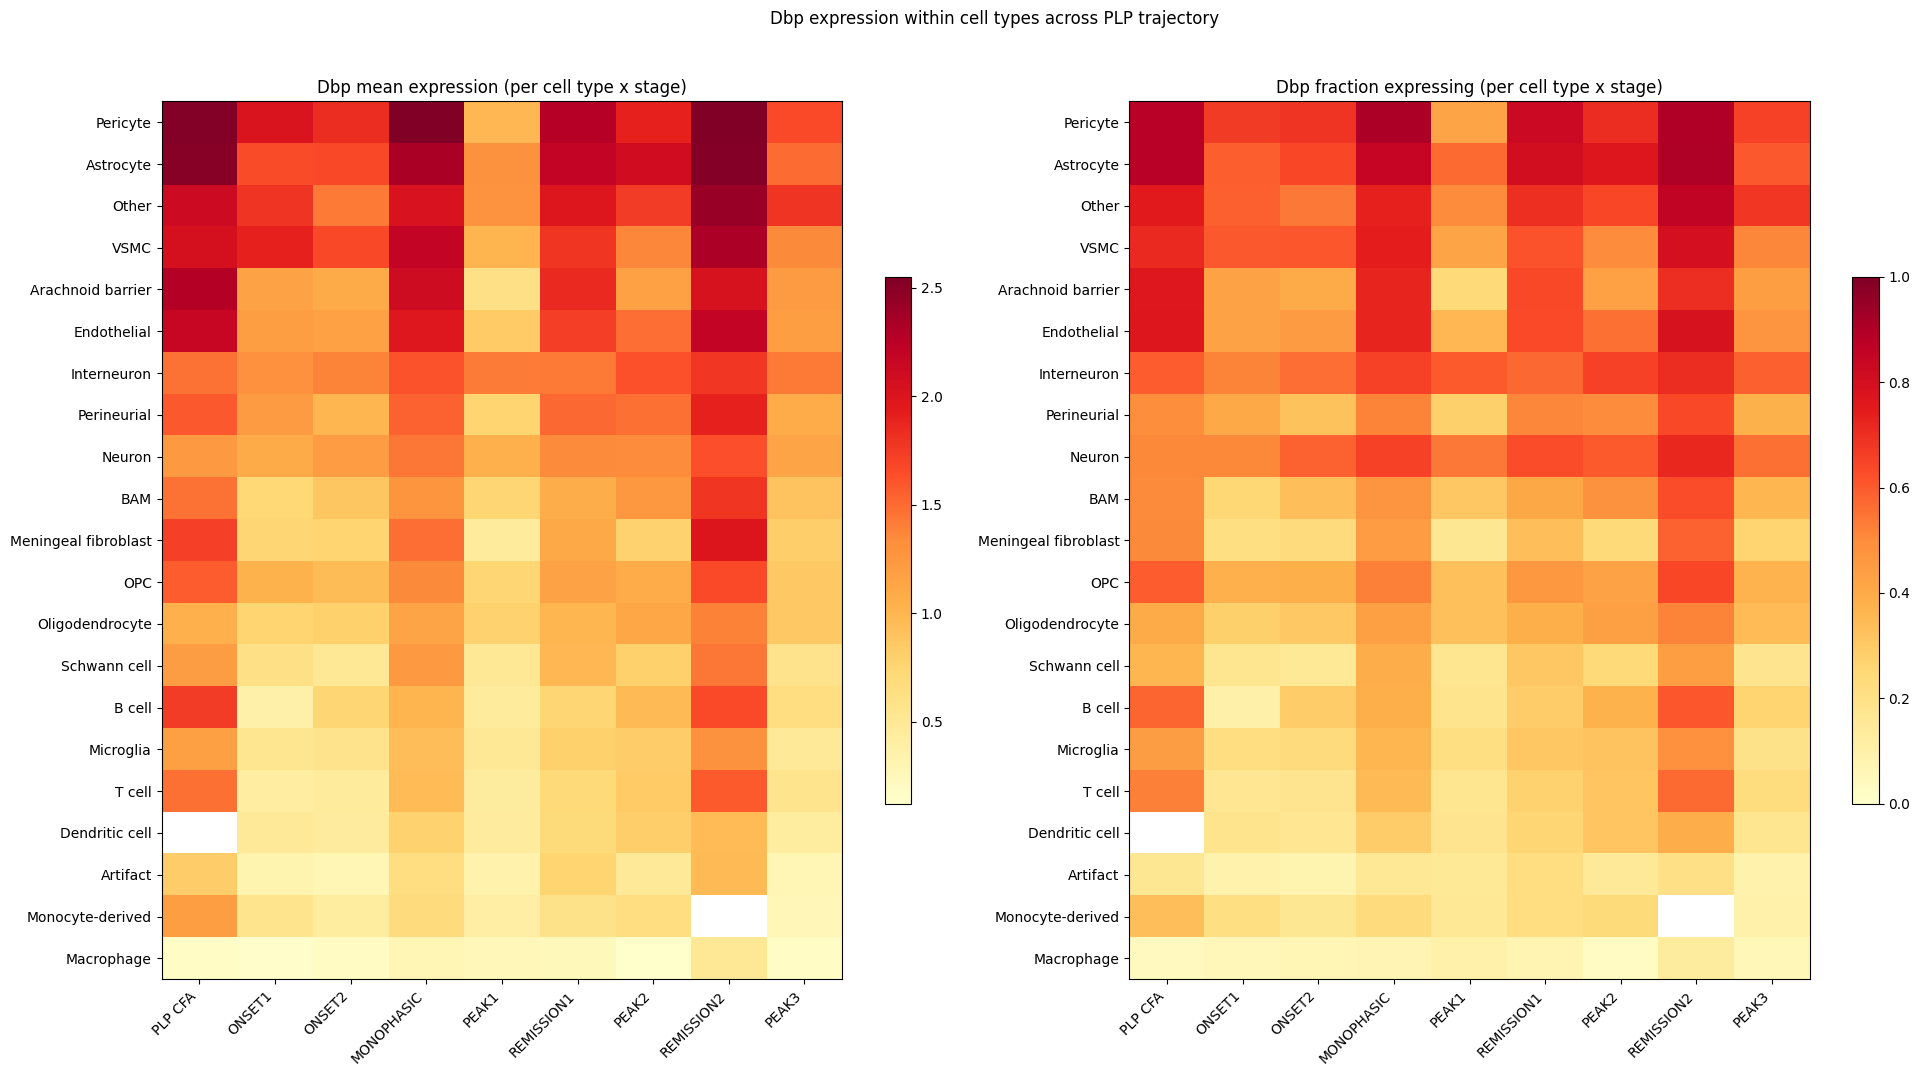

In [9]:
# Heatmap: Dbp expression per (cell type x stage)
plp_stages = get_all_stages()['PLP']
dbp_idx = list(plp.var_names).index('Dbp')

heatmap = np.zeros((len(expressing_cts), len(plp_stages)))
frac_map = np.zeros_like(heatmap)

for i, ct in enumerate(expressing_cts):
    for j, stage in enumerate(plp_stages):
        mask = (plp.obs[CELL_TYPE_KEY] == ct) & (plp.obs[STAGE_KEY] == stage)
        if mask.sum() < 10:
            heatmap[i, j] = np.nan
            frac_map[i, j] = np.nan
            continue
        vals = plp[mask].X[:, dbp_idx]
        if sparse.issparse(vals):
            vals = np.asarray(vals.todense()).flatten()
        heatmap[i, j] = vals.mean()
        frac_map[i, j] = (vals > 0).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, max(4, len(expressing_cts) * 0.5)))

# Mean expression
im1 = ax1.imshow(heatmap, aspect='auto', cmap='YlOrRd')
ax1.set_xticks(range(len(plp_stages)))
ax1.set_xticklabels(plp_stages, rotation=45, ha='right')
ax1.set_yticks(range(len(expressing_cts)))
ax1.set_yticklabels(expressing_cts)
ax1.set_title('Dbp mean expression (per cell type x stage)')
plt.colorbar(im1, ax=ax1, shrink=0.6)

# Fraction expressing
im2 = ax2.imshow(frac_map, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax2.set_xticks(range(len(plp_stages)))
ax2.set_xticklabels(plp_stages, rotation=45, ha='right')
ax2.set_yticks(range(len(expressing_cts)))
ax2.set_yticklabels(expressing_cts)
ax2.set_title('Dbp fraction expressing (per cell type x stage)')
plt.colorbar(im2, ax=ax2, shrink=0.6)

plt.suptitle('Dbp expression within cell types across PLP trajectory', y=1.02)
plt.tight_layout()
plt.show()



Pericyte (6,064 cells across 9 stages)


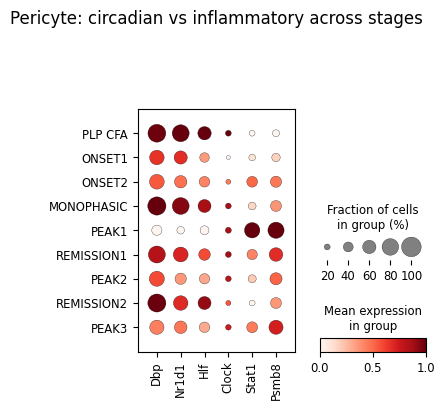


Astrocyte (69,327 cells across 9 stages)


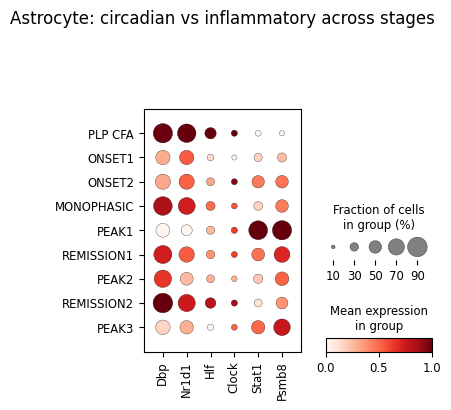


Other (3,803 cells across 9 stages)


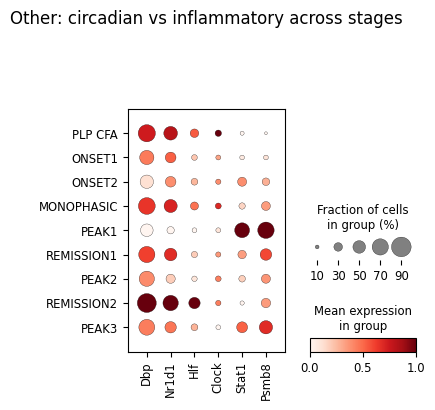


VSMC (5,074 cells across 9 stages)


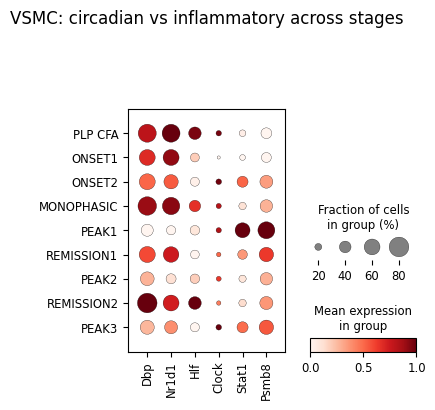


Arachnoid barrier (10,772 cells across 9 stages)


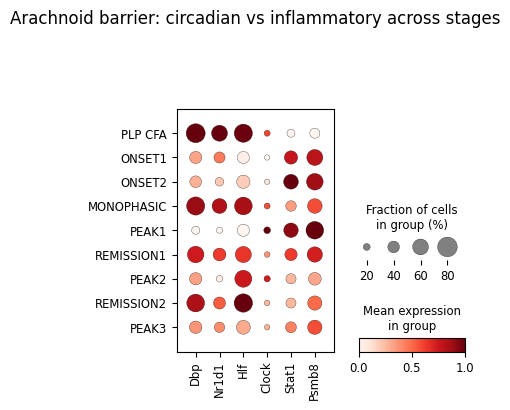


Endothelial (40,018 cells across 9 stages)


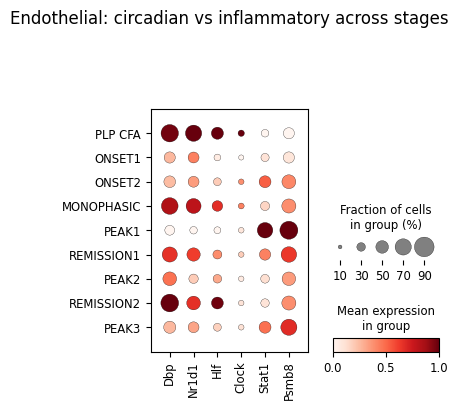


Interneuron (83,708 cells across 9 stages)


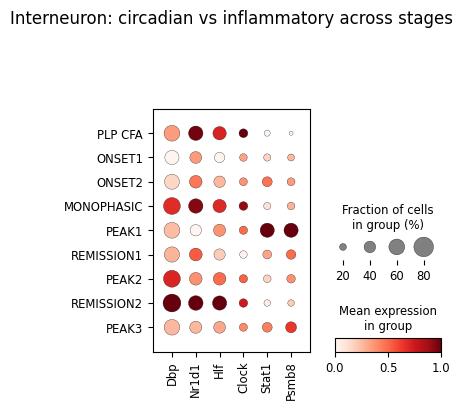


Perineurial (4,587 cells across 9 stages)


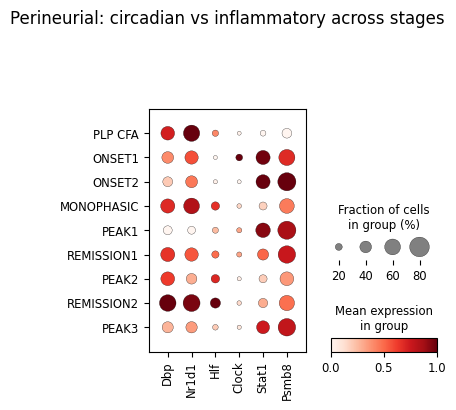


Neuron (29,210 cells across 9 stages)


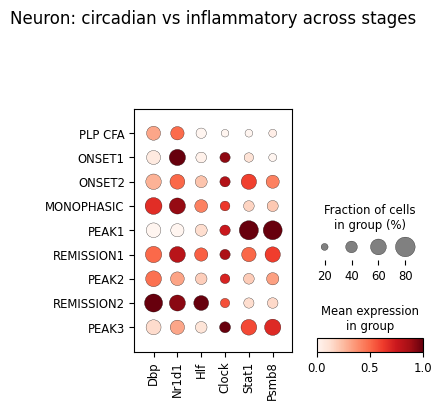


BAM (10,427 cells across 9 stages)


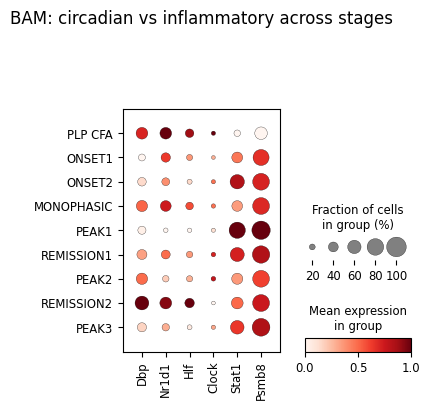


Meningeal fibroblast (30,748 cells across 9 stages)


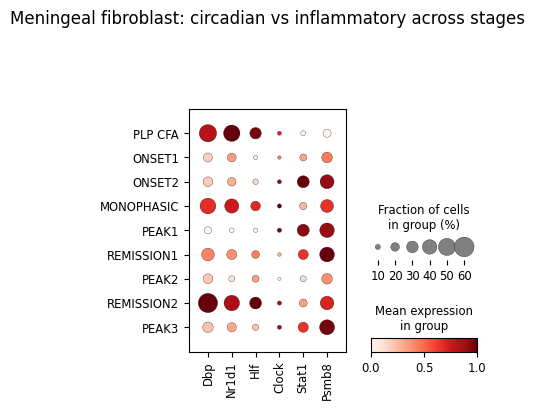


OPC (15,916 cells across 9 stages)


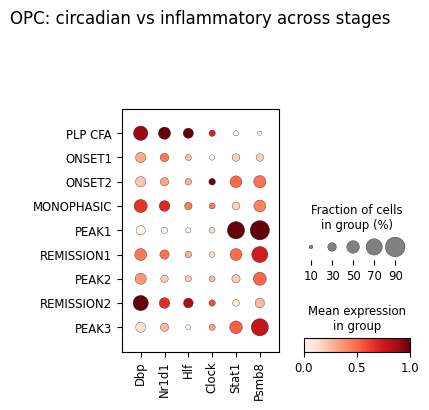


Oligodendrocyte (119,979 cells across 9 stages)


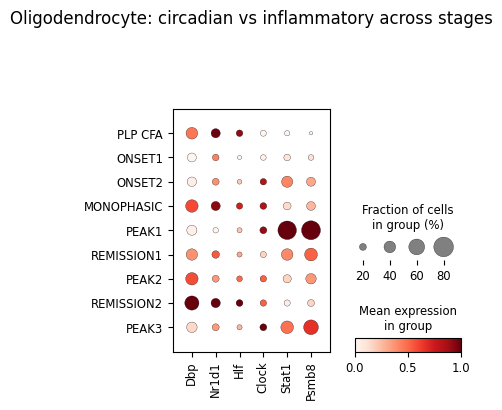


Schwann cell (13,915 cells across 9 stages)


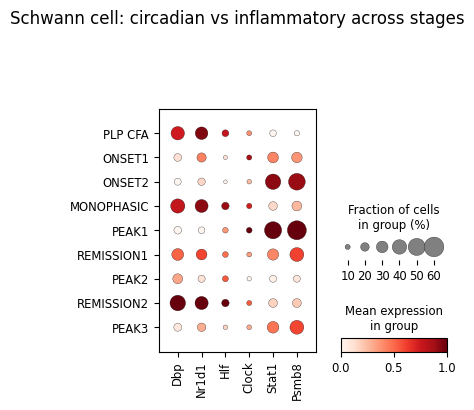


B cell (9,286 cells across 9 stages)


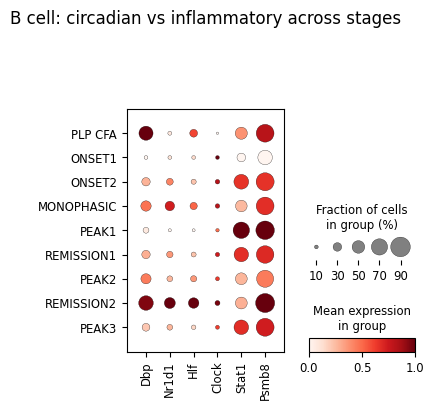

In [12]:
# Same analysis for all three circadian genes — dotplot per cell type across stages
# Use scanpy's built-in grouped dotplot for a cleaner view

for ct in expressing_cts[:15]:  # top 6 expressing cell types
    sub = plp[(plp.obs[CELL_TYPE_KEY] == ct)].copy()
    sub.obs[STAGE_KEY] = pd.Categorical(sub.obs[STAGE_KEY], categories=plp_stages, ordered=True)
    
    n_per_stage = sub.obs[STAGE_KEY].value_counts()
    enough = n_per_stage[n_per_stage >= 10].index
    sub = sub[sub.obs[STAGE_KEY].isin(enough)].copy()
    
    inflam = ['Stat1', 'Psmb8']
    inflam_present = [g for g in inflam if g in plp.var_names]
    genes_to_plot = clock_present +['Clock'] + inflam_present 
    
    print(f"\n{ct} ({sub.n_obs:,} cells across {len(enough)} stages)")
    sc.pl.dotplot(sub, var_names=genes_to_plot, groupby=STAGE_KEY,
                  standard_scale='var',
                  title=f'{ct}: circadian vs inflammatory across stages')
    plt.show()


## Summary

**If the peak-suppression pattern holds within individual cell types** (each row
of the heatmap shows low Dbp at PEAK1/PEAK3 and high at baseline/remissions),
then the circadian disruption is **cell-intrinsic** — inflammatory signaling
within each cell suppresses clock output. This rules out a composition
artifact and supports NF-kB-mediated clock disruption as a real mechanism.

**If the pattern is only visible in certain cell types**, those are the cell
types where the circadian-inflammatory axis operates. Look for:
- **Astrocytes**: major circadian gene expressors in the CNS
- **Oligodendrocytes**: `Nr1d1` regulates myelination
- **Microglia/macrophages**: `Nr1d1` directly represses inflammatory gene
  expression; most direct link to the IFN-gamma storm
